# QuickCart Warehouse Inventory Stockout Risk
### Supervised ML Classification Project

**Goal:** Predict `Safe`, `At-Risk`, or `Imminent` stockout risk per SKU, store and day.

The project specification recommends a time-based split because the same store-SKU pair appears across multiple days, and it emphasizes recall for the rare **Imminent** class.

In [2]:
# 2. Imports and data loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score
)

events = pd.read_csv('dim_events.csv', parse_dates=['date'])
skus = pd.read_csv('dim_skus.csv')
stores = pd.read_csv('dim_stores.csv')
suppliers = pd.read_csv(
    'dim_suppliers.csv',
    na_values=['N/A', 'missing', '--', 'NA', 'null'],
    keep_default_na=True
)
fact = pd.read_csv('fact_inventory_daily.csv', parse_dates=['date'])

print('events:', events.shape)
print('skus:', skus.shape)
print('stores:', stores.shape)
print('suppliers:', suppliers.shape)
print('fact:', fact.shape)

events: (30, 5)
skus: (60, 9)
stores: (12, 8)
suppliers: (15, 6)
fact: (21600, 16)


## 3. Sanity checks
These should match the locked figures in the project specification.

In [3]:
print('--- Row counts ---')
print('Stores:', len(stores))
print('SKUs:', len(skus))
print('Suppliers:', len(suppliers))
print('Events:', len(events))
print('Fact:', len(fact))

print('\n--- Target distribution ---')
print(fact['stockout_risk'].value_counts())
print((fact['stockout_risk'].value_counts(normalize=True) * 100).round(2))

print('\n--- Date range ---')
print(fact['date'].min().date(), 'to', fact['date'].max().date())
print('Unique dates:', fact['date'].nunique())

print('\n--- Missing actual lead time ---')
print(fact['lead_time_days_actual'].isna().sum())

print('\n--- City casing issue ---')
print(stores.loc[stores['city_display'] != stores['city'], ['store_id','city','city_display']])

--- Row counts ---
Stores: 12
SKUs: 60
Suppliers: 15
Events: 30
Fact: 21600

--- Target distribution ---
stockout_risk
Safe        14131
At-Risk      5186
Imminent     2283
Name: count, dtype: int64
stockout_risk
Safe        65.42
At-Risk     24.01
Imminent    10.57
Name: proportion, dtype: float64

--- Date range ---
2026-10-01 to 2026-10-30
Unique dates: 30

--- Missing actual lead time ---
19899

--- City casing issue ---
  store_id       city city_display
2     ST03  Bengaluru    BENGALURU
8     ST09  Hyderabad    hyderabad


## 4. Merge the five tables
The fact table is the modeling table. Join stores, SKUs, suppliers and events to it using the documented keys.

In [4]:
df = (
    fact
    .merge(stores, on='store_id', how='left')
    .merge(skus, on='sku_id', how='left', suffixes=('', '_sku'))
    .merge(suppliers, on='supplier_id', how='left', suffixes=('', '_sup'))
    .merge(events, on='date', how='left', suffixes=('', '_event'))
)

print('Merged shape:', df.shape)
print('Missing values after merge:')
print(df.isna().sum().sort_values(ascending=False).head(15))

Merged shape: (21600, 40)
Missing values after merge:
lead_time_days_actual    19899
reliability_score         5040
date                         0
store_id                     0
opening_stock                0
units_demanded               0
sku_id                       0
supplier_id                  0
closing_stock                0
units_sold                   0
reorder_placed               0
reorder_point                0
sales_velocity_7d            0
days_of_cover                0
is_festival_week             0
dtype: int64


## 5. Data cleaning and feature engineering

Derived features follow the project guidance:
- `reorder_gap`
- `days_of_cover_ratio`
- cleaned supplier reliability
- recent reorder flag
- temporal features
- categorical variables

In [5]:
# Standardize display-only city text
df['city_display'] = df['city_display'].str.title()

# Clean supplier reliability: N/A -> NaN, then median imputation
df['supplier_reliability_clean'] = (
    df['reliability_score']
    .fillna(df['reliability_score'].median())
)

# Suggested engineered features
df['reorder_gap'] = df['reorder_point'] - df['closing_stock']
df['days_of_cover_ratio'] = (
    df['days_of_cover'] /
    df['lead_time_days_expected'].replace(0, np.nan)
)

df['day_of_month'] = df['date'].dt.day

# Days from the start of Diwali week (Oct 22)
df['days_since_festival_start'] = (
    df['date'] - pd.Timestamp('2026-10-22')
).dt.days.clip(lower=0)

# Whether a reorder happened during the previous 3 days
df = df.sort_values(['store_id', 'sku_id', 'date']).copy()
df['is_recent_reorder'] = (
    df.groupby(['store_id', 'sku_id'])['reorder_placed']
      .transform(lambda s:
          s.shift(1).eq('Y').rolling(3, min_periods=1).max()
      )
      .astype(int)
)

print(df[['reorder_gap','days_of_cover_ratio',
          'supplier_reliability_clean','is_recent_reorder']].head())

   reorder_gap  days_of_cover_ratio  supplier_reliability_clean  \
0       -108.5                 9.66                        0.83   
1        -98.5                10.79                        0.83   
2        -83.5                 8.99                        0.83   
3        -73.5                 8.79                        0.83   
4        -64.5                 8.55                        0.83   

   is_recent_reorder  
0                  0  
1                  0  
2                  0  
3                  0  
4                  0  


## 6. Exploratory analysis

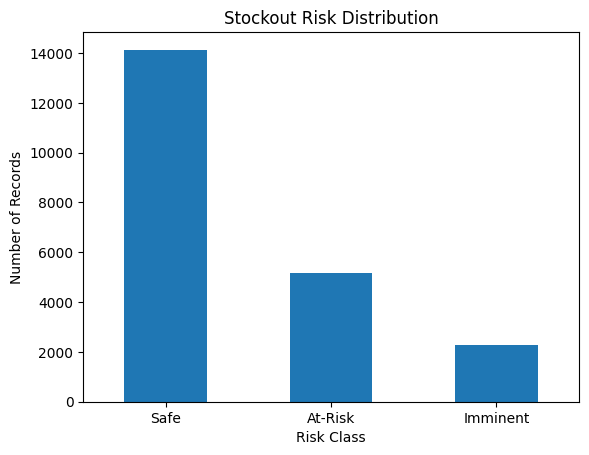

Imminent rate by festival week:
is_festival_week
N     9.51
Y    23.31
Name: stockout_risk, dtype: float64

Imminent rate by perishability:
is_perishable
N     9.30
Y    12.77
Name: stockout_risk, dtype: float64


In [6]:
# Target distribution
df['stockout_risk'].value_counts().plot(kind='bar')
plt.title('Stockout Risk Distribution')
plt.xlabel('Risk Class')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

# Festival vs non-festival imminent rate
festival_rate = df.groupby('is_festival_week')['stockout_risk'].apply(
    lambda x: (x == 'Imminent').mean() * 100
)
print('Imminent rate by festival week:')
print(festival_rate.round(2))

# Perishable vs non-perishable
perishable_rate = df.groupby('is_perishable')['stockout_risk'].apply(
    lambda x: (x == 'Imminent').mean() * 100
)
print('\nImminent rate by perishability:')
print(perishable_rate.round(2))

## 7. Time-based train/test split
Train: **Oct 1–23, 2026**  
Test: **Oct 24–30, 2026**

This avoids random row-level leakage between repeated store-SKU pairs.

In [7]:
train = df[df['date'] <= '2026-10-23'].copy()
test = df[df['date'] >= '2026-10-24'].copy()

print('Train rows:', len(train))
print('Test rows:', len(test))
print('Train dates:', train['date'].min().date(), 'to', train['date'].max().date())
print('Test dates:', test['date'].min().date(), 'to', test['date'].max().date())

Train rows: 16560
Test rows: 5040
Train dates: 2026-10-01 to 2026-10-23
Test dates: 2026-10-24 to 2026-10-30


In [10]:
# 8. Select features
features = [
    'opening_stock', 'units_demanded', 'units_sold', 'closing_stock',
    'reorder_point', 'lead_time_days_expected', 'sales_velocity_7d',
    'days_of_cover', 'reorder_gap', 'days_of_cover_ratio',
    'supplier_reliability_clean', 'is_recent_reorder',
    'day_of_month', 'days_since_festival_start', 'is_festival_week',
    'store_size', 'category', 'is_perishable',
    'festive_relevant', 'popularity_tier'
]

X_train = train[features]
X_test = test[features]
y_train = train['stockout_risk']
y_test = test['stockout_risk']

categorical = [
    'store_size', 'category', 'is_perishable',
    'festive_relevant', 'popularity_tier', 'is_festival_week'
]
numeric = [c for c in features if c not in categorical]

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical)
])

## 9. Baseline
The majority-class baseline is important because the dataset is imbalanced.

In [9]:
majority_class = y_train.mode()[0]
baseline_pred = np.full(len(y_test), majority_class)

print('Majority class:', majority_class)
print('Baseline accuracy:', round(accuracy_score(y_test, baseline_pred), 4))
print(classification_report(y_test, baseline_pred, zero_division=0))

Majority class: Safe
Baseline accuracy: 0.6228
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



## 10. Train three classification models
- Multinomial Logistic Regression
- Random Forest
- Gradient Boosting

For this project, pay particular attention to **recall for Imminent**.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

results = []
fitted = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    imminent_recall = recall_score(
        y_test, pred, labels=['Imminent'], average=None
    )[0]
    imminent_f1 = f1_score(
        y_test, pred, labels=['Imminent'], average=None
    )[0]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, pred),
        'Imminent Recall': imminent_recall,
        'Imminent F1': imminent_f1
    })
    fitted[name] = pipe

results_df = pd.DataFrame(results).sort_values(
    'Imminent Recall', ascending=False
)
results_df

,Model,Accuracy,Balanced Accuracy,Imminent Recall,Imminent F1
0,Logistic Regression,0.852778,0.786753,0.992258,0.690925
2,Gradient Boosting,0.950794,0.902484,0.762581,0.828311
1,Random Forest,0.931151,0.858830,0.624516,0.741194


              precision    recall  f1-score   support

     At-Risk       0.85      0.95      0.90      1126
    Imminent       0.91      0.76      0.83       775
        Safe       1.00      1.00      1.00      3139

    accuracy                           0.95      5040
   macro avg       0.92      0.90      0.91      5040
weighted avg       0.95      0.95      0.95      5040

Confusion matrix:
[[3136    3    0]
 [   0 1065   61]
 [   0  184  591]]


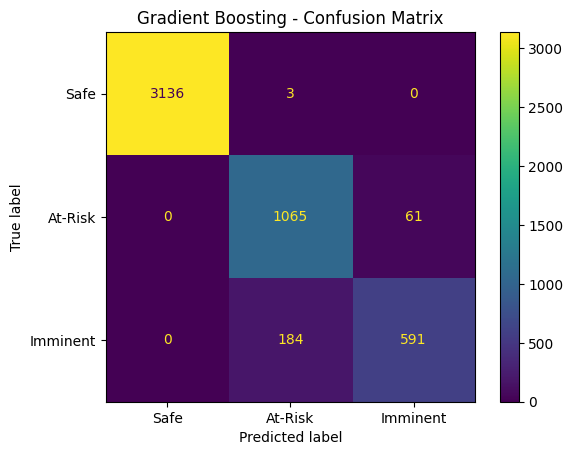

In [12]:
# 11. Detailed evaluation of Gradient Boosting
# Gradient Boosting has the highest accuracy, balanced accuracy and Imminent F1.
selected_model = fitted['Gradient Boosting']
best_pred = selected_model.predict(X_test)

print(classification_report(y_test, best_pred, zero_division=0))

cm = confusion_matrix(
    y_test, best_pred,
    labels=['Safe', 'At-Risk', 'Imminent']
)

print('Confusion matrix:')
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Safe', 'At-Risk', 'Imminent']
)
disp.plot()
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

## 12. Feature importance
Gradient Boosting provides feature importances after preprocessing.

num__days_of_cover                   0.412783
num__reorder_gap                     0.312535
num__days_of_cover_ratio             0.234392
num__supplier_reliability_clean      0.022632
num__reorder_point                   0.003625
num__closing_stock                   0.002591
num__opening_stock                   0.002290
num__day_of_month                    0.002280
num__is_recent_reorder               0.001686
num__sales_velocity_7d               0.001593
num__units_demanded                  0.001126
cat__is_perishable_N                 0.000854
num__units_sold                      0.000425
num__lead_time_days_expected         0.000413
cat__category_Fruits & Vegetables    0.000192
dtype: float64


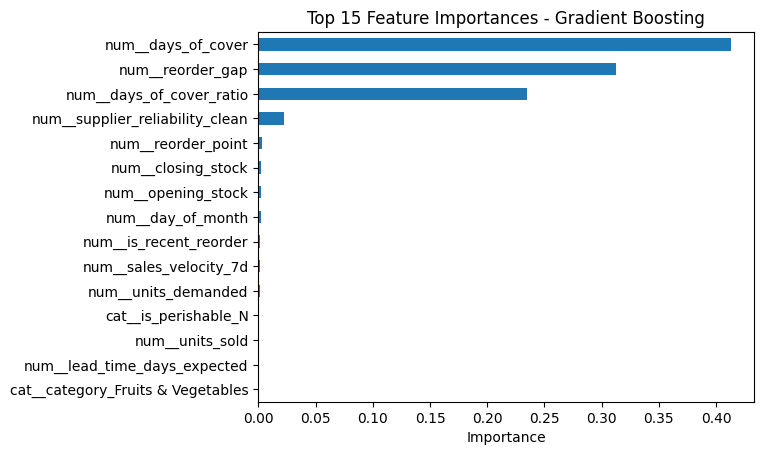

In [14]:
# Get transformed feature names
pre = selected_model.named_steps['preprocessor']
gb = selected_model.named_steps['model']

feature_names = pre.get_feature_names_out()
importance = pd.Series(
    gb.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importance.head(15))

importance.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances - Gradient Boosting')
plt.xlabel('Importance')
plt.show()

## 13. Final conclusion template

Use the actual values printed above in your report.

**Suggested conclusion:**  
The QuickCart model was developed as a three-class stockout-risk classifier using data from multiple relational tables. After cleaning the supplier reliability field, standardizing city labels and engineering inventory, demand, supplier and temporal features, the models were evaluated using a time-based split. The evaluation should emphasize recall for the Imminent class because missing an impending stockout has greater operational consequences than generating a false alert. The final model and numerical results should be reported using the outputs generated in this notebook.